In [2]:
from DDiT import Disk
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Disk parameters
disk_params = {
    'nx' : 300,             # Size of the image in pixels
    'pixscale' : 0.01226,   # Size of one pixel in arcseconds
    'nframe' : 50,          # Number of frames (see above)
    'thermal' : False,       # A boolean
    'dpc' : 35.34,          # Distance of the central star in pc
}
disk = Disk(**disk_params)

In [4]:
def normalized_data(data):
    # Normalize the data to the range 0-255
    return (data - np.min(data)) / (np.max(data) - np.min(data)) * 255

def dict_to_string(d):
    return '-'.join(f'{key}{value}' for key, value in d.items())

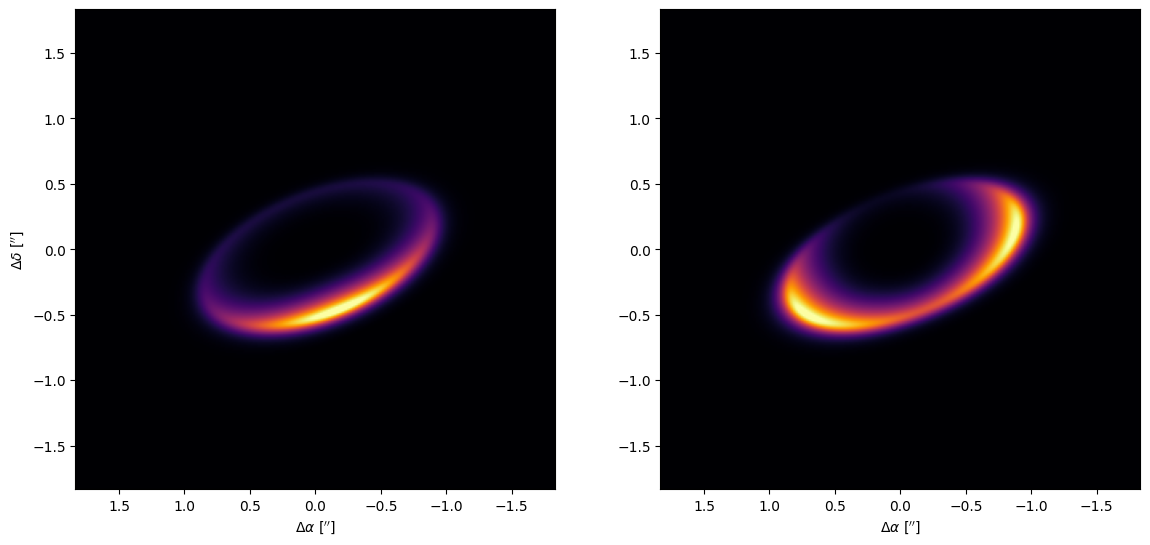

(300, 300)


In [5]:
from PIL import Image

# Compute model parameters
model_params = {
    'a' : 0.95,             # Semi-major axis of the disk in arcseconds
    'incl' : 60.,           # Inclination, in degrees
    'pa' : 112.,            # Position angle, in degrees
    'pin' : 5.0,            # Inner slope of the density distribution (>0)
    'pout' : -15.0,         # Outer slope of the density distribution (<0)
    'e' : 0.1,              # Eccentricity
    'omega' : 85.,          # Argument of periapsis, in degrees
    'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
    'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
    'opang' : 0.03,         # Opening angle of the disk, in radians
}
disk.compute_model(**model_params)
disk.plot()
print(disk.polarized.shape)

# Save the intensity image
intensity_image = Image.fromarray(normalized_data(disk.intensity).astype(np.uint8), 'L')
intensity_image.save('output/images/{}_intensity.bmp'.format(dict_to_string(model_params)))

# Save the polarized image
polarized_image = Image.fromarray(normalized_data(disk.polarized).astype(np.uint8), 'L')
polarized_image.save('output/images/{}_polarized.bmp'.format(dict_to_string(model_params)))

# Save the azimuth image
azimuth_image = Image.fromarray(normalized_data(disk.azimuth).astype(np.uint8), 'L')
azimuth_image.save('output/images/{}_azimuth.bmp'.format(dict_to_string(model_params)))

In [6]:
# Compute model parameters
model_params = {
    'a' : np.array([0.95, 1.5]),             # Semi-major axis of the disk in arcseconds
    'incl' : [60., 110.],           # Inclination, in degrees
    'pa' : 112.,            # Position angle, in degrees
    'pin' : 5.0,            # Inner slope of the density distribution (>0)
    'pout' : -15.0,         # Outer slope of the density distribution (<0)
    'e' : 0.1,              # Eccentricity
    'omega' : 85.,          # Argument of periapsis, in degrees
    'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
    'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
    'opang' : 0.03,         # Opening angle of the disk, in radians
}

In [7]:
def recursive_compute_model(params, input_disk):
    for key, value in params.items():
        # If list in the 
        if isinstance(value, list) or isinstance(value, np.ndarray):
            for v in value:
                temp_params = params.copy()
                temp_params[key] = v
                recursive_compute_model(temp_params, input_disk)
            return
    print("a : {}, incl : {}".format(params['a'], params['incl']))
    input_disk.compute_model(**params)
    input_disk.plot()

a : 0.95, incl : 60.0


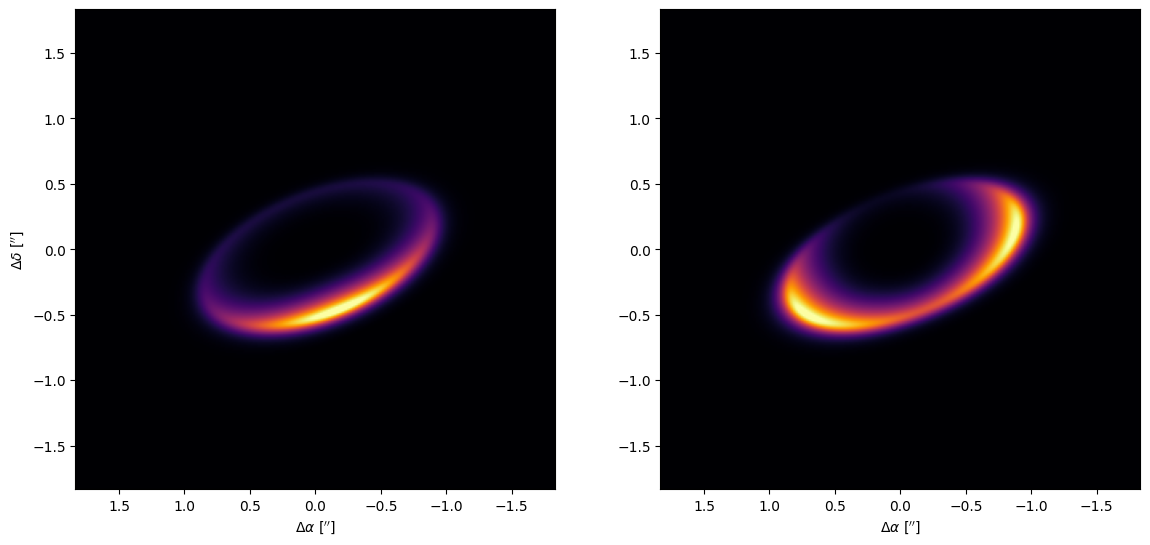

a : 0.95, incl : 110.0


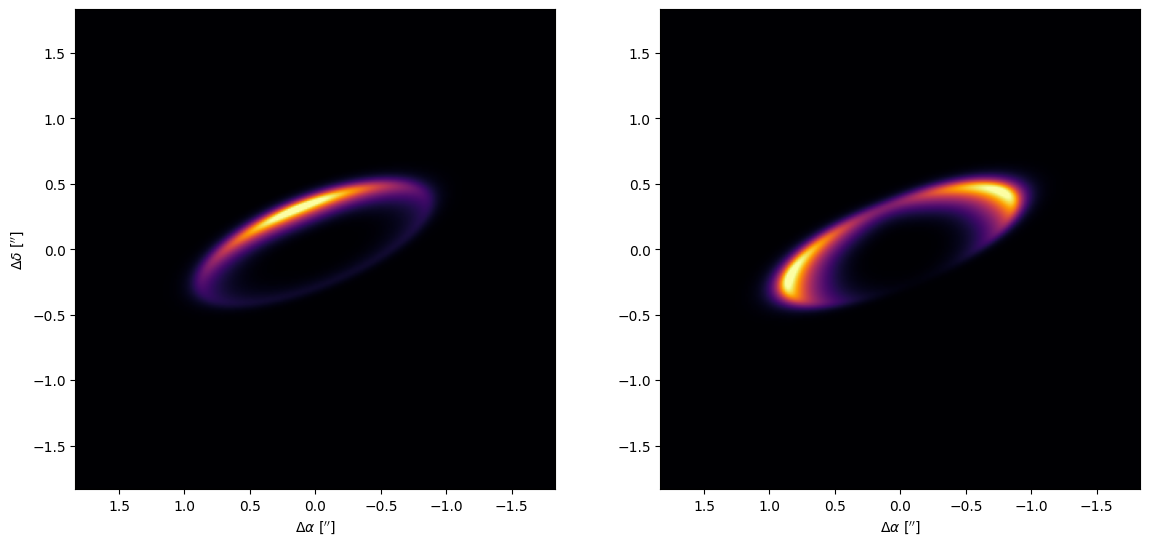

a : 1.5, incl : 60.0


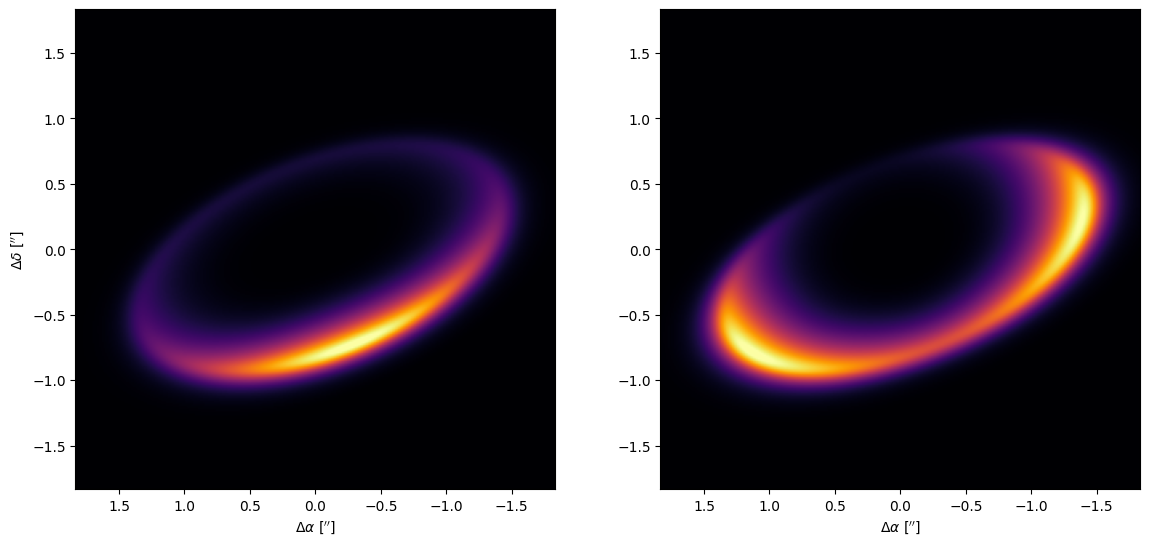

a : 1.5, incl : 110.0


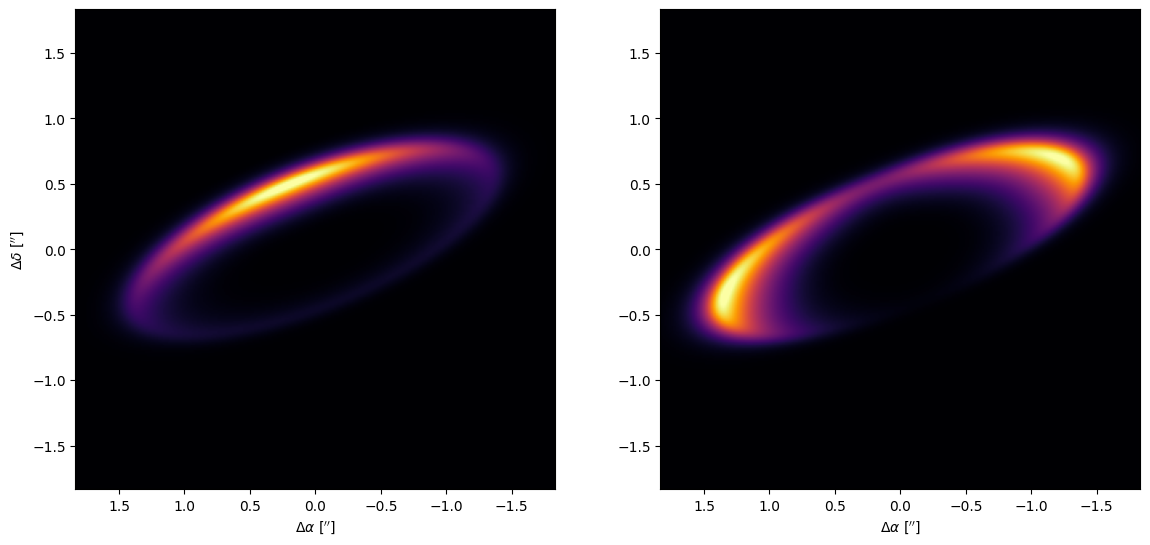

In [8]:
recursive_compute_model(model_params, disk)

Took: 0.76 seconds.
(300, 300)


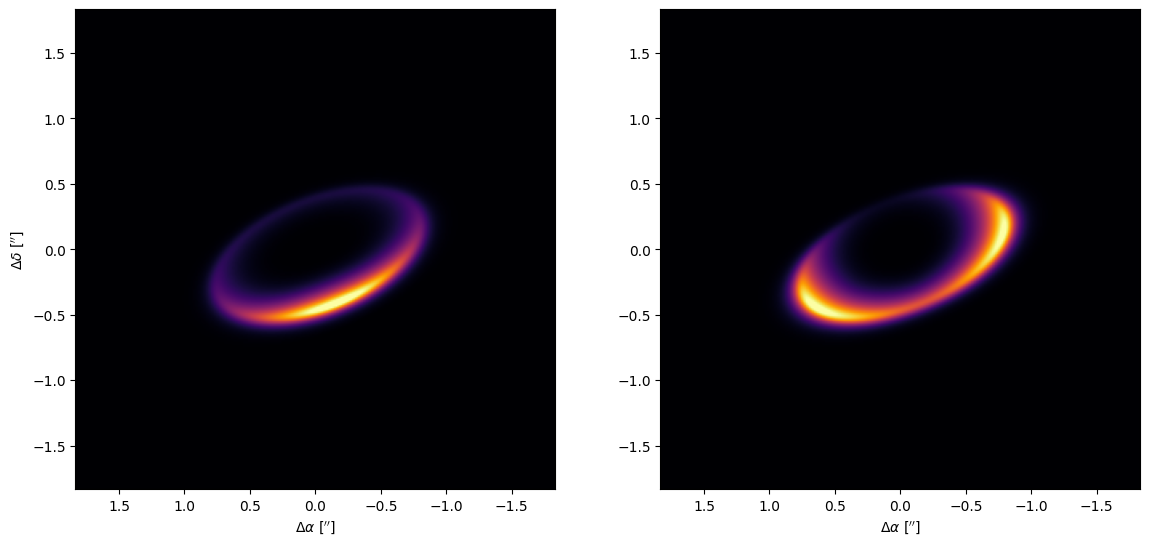

In [23]:
import time

disk = Disk(**disk_params)
#disk = Disk(nx, pixscale, nframe, thermal, dpc)
t0 = time.time()
disk.compute_model(**model_params)
print('Took: ' + format(time.time()-t0, '0.2f') + ' seconds.')
print(disk.intensity.shape)
disk.plot()

In [6]:
disk.intensity.shape

(300, 300)

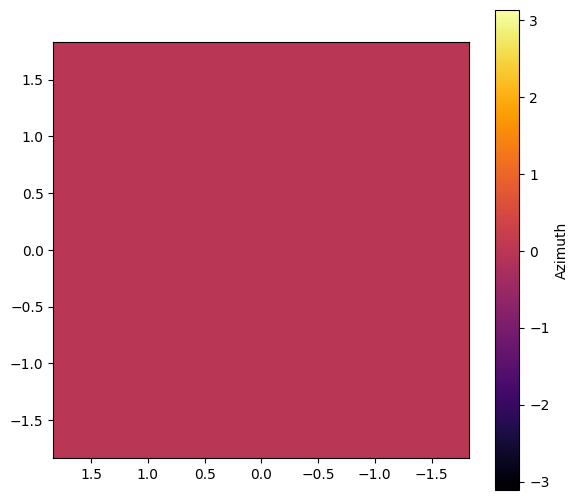

In [35]:
fig = plt.figure(figsize=(13,6))
cmap = 'inferno'
data = disk.polarized
cax = fig.add_axes([0.52, 0.12, 0.4, 0.8])
im2 = cax.imshow(data, origin='lower', extent=[disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap=cmap, vmin=np.percentile(disk.azimuth, 1.), vmax=np.percentile(disk.azimuth, 99.9))
cbar = fig.colorbar(im2, ax=cax, orientation='vertical')
cbar.set_label('Azimuth')

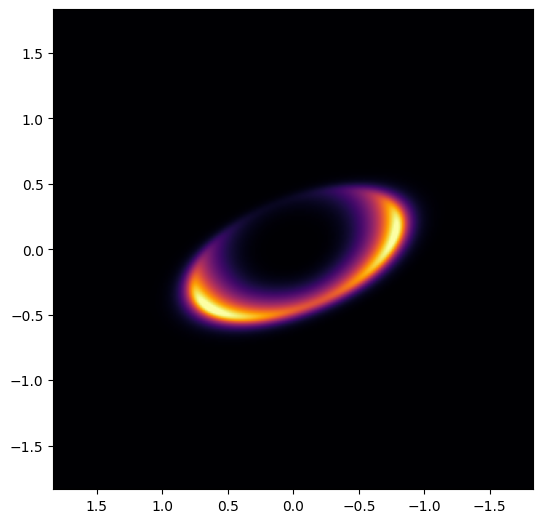

In [36]:
fig = plt.figure(figsize=(13,6))
cmap = 'inferno'
data = disk.polarized
ax1 = fig.add_axes([0.1, 0.12, 0.4, 0.8])
im = ax1.imshow(data, origin = 'lower', extent = [disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap = cmap, vmin = np.percentile(data, 1.), vmax = np.percentile(data, 99.9))

